# BCA Analysis - Biomek 4000 (file: bca_absorbance_3.csv)

This notebook analyses absorbance data from a BCA protein assay performed on a Biomek 4000 robot.

**BCA assay principle:**  
Under alkaline conditions, proteins reduce Cu2+ to Cu+. The Cu+ ion then forms a purple complex with bicinchoninic acid (BCA), absorbing at 562 nm (measured here at 595 nm).  
Absorbance is proportional to protein concentration.

**File structure:**
- Each BSA standard is its own `Experiment` entry: `Triplicate 1_1` to `Triplicate 1_9` + `Blank 1`
- 3 groups of experimental triplicates (Triplicate 1, 2, 3)
- 3 technical reads (`Read = 1, 2, 3`) per entry

**Order of operations:**
1. Subtract the blank from the same group and the same technical read (Read)
2. Average the 3 technical reads
3. Statistics by BSA concentration
4. Linear regression and calibration curve
5. Calculate Prot X concentrations

## Section 2: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

print('Libraries imported successfully.')

Libraries imported successfully.


## Section 3: Load Data

The CSV file uses `;` as separator and contains 4 columns: `Read`, `Experiment`, `Absorbance`, `Well`.

In [2]:
df = pd.read_csv('bca_absorbance_3.csv', sep=';')

print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'Technical reads: {sorted(df["Read"].unique())}')
print(f'Unique experiments: {df["Experiment"].nunique()}')
print()
print('Data preview:')
df.head(12)

Shape: 102 rows x 4 columns
Technical reads: [np.int64(1), np.int64(2), np.int64(3)]
Unique experiments: 34

Data preview:


,Read,Experiment,Absorbance,Well
0,1,Triplicate 1_1,0.977,1
1,1,Triplicate 1_2,0.772,13
2,1,Triplicate 1_3,0.571,25
3,1,Triplicate 1_4,0.607,37
4,1,Triplicate 1_5,0.397,49
5,1,Triplicate 1_6,0.346,61
6,1,Triplicate 1_7,0.313,73
7,1,Triplicate 1_8,0.257,85
8,1,Triplicate 1_9,0.239,2
9,1,Blank 1,0.108,14


## Section 4: Convert Well Numbers to IDs

The robot numbers wells from 1 to 96 (column by column).  
We convert them to standard identifiers: A1, B3, etc.

**Conversion formula:**
- Row (letter) = `(number - 1) // 12` -> index in A-H
- Column (digit) = `(number - 1) % 12 + 1`

In [3]:
rows = list('ABCDEFGH')

def number_to_id(n):
    letter = rows[(n - 1) // 12]
    column = (n - 1) % 12 + 1
    return f'{letter}{column}'

df['Well_ID'] = df['Well'].apply(number_to_id)
df['Row']    = df['Well_ID'].str[0]
df['Column'] = df['Well_ID'].str[1:].astype(int)

print('Conversion examples:')
df[['Well', 'Well_ID', 'Row', 'Column']].drop_duplicates().head(10)

Conversion examples:


,Well,Well_ID,Row,Column
0,1,A1,A,1
1,13,B1,B,1
2,25,C1,C,1
3,37,D1,D,1
4,49,E1,E,1
5,61,F1,F,1
6,73,G1,G,1
7,85,H1,H,1
8,2,A2,A,2
9,14,B2,B,2


## Section 5: Identify Standards, Blanks, and Unknowns

Each entry is classified by type:
- **BSA_standard**: `Triplicate X_Y` (standards with known concentration)
- **Blank**: `Blank X` (no protein)
- **Unknown**: `Prot X_*` (samples to quantify)

We also extract the group number (1, 2, or 3) to associate each standard with its corresponding blank.

In [4]:
# BSA concentrations: suffix _1=1.0, _2=0.9, ..., _9=0.2 mg/mL; Blank=0.0
CONC_SUFFIX = {
    '1': 1.0, '2': 0.9, '3': 0.8, '4': 0.7, '5': 0.6,
    '6': 0.5, '7': 0.4, '8': 0.3, '9': 0.2
}

# Dilution factors for unknowns
DILUTION_FACTORS = {
    'Prot X_stock':  1,
    'Prot X_d2':     2,
    'Prot X_d5':     5,
    'Prot X_d10':   10
}

def get_sample_type(exp):
    if exp.startswith('Triplicate'):
        return 'BSA_standard'
    elif exp.startswith('Blank'):
        return 'Blank'
    else:
        return 'Unknown'

def get_group(exp):
    if exp.startswith('Triplicate'):
        return int(exp.split(' ')[1].split('_')[0])
    elif exp.startswith('Blank'):
        return int(exp.split(' ')[1])
    else:
        return None

def get_bsa_conc(exp):
    if exp.startswith('Triplicate'):
        suffix = exp.split('_')[1]
        return CONC_SUFFIX.get(suffix, np.nan)
    elif exp.startswith('Blank'):
        return 0.0
    else:
        return np.nan

df['Sample_Type']             = df['Experiment'].apply(get_sample_type)
df['Group']                   = df['Experiment'].apply(get_group)
df['BSA_concentration_mg_mL'] = df['Experiment'].apply(get_bsa_conc)
df['Dilution_factor']         = df['Experiment'].map(DILUTION_FACTORS).fillna(1.0)

print('Sample type breakdown:')
print(df[['Experiment', 'Sample_Type', 'Group', 'BSA_concentration_mg_mL']]
      .drop_duplicates()
      .sort_values(['Sample_Type', 'Group', 'BSA_concentration_mg_mL'], ascending=[True, True, False])
      .to_string(index=False))

Sample type breakdown:
    Experiment  Sample_Type  Group  BSA_concentration_mg_mL
Triplicate 1_1 BSA_standard    1.0                      1.0
Triplicate 1_2 BSA_standard    1.0                      0.9
Triplicate 1_3 BSA_standard    1.0                      0.8
Triplicate 1_4 BSA_standard    1.0                      0.7
Triplicate 1_5 BSA_standard    1.0                      0.6
Triplicate 1_6 BSA_standard    1.0                      0.5
Triplicate 1_7 BSA_standard    1.0                      0.4
Triplicate 1_8 BSA_standard    1.0                      0.3
Triplicate 1_9 BSA_standard    1.0                      0.2
Triplicate 2_1 BSA_standard    2.0                      1.0
Triplicate 2_2 BSA_standard    2.0                      0.9
Triplicate 2_3 BSA_standard    2.0                      0.8
Triplicate 2_4 BSA_standard    2.0                      0.7
Triplicate 2_5 BSA_standard    2.0                      0.6
Triplicate 2_6 BSA_standard    2.0                      0.5
Triplicate 2_7 BS

## Section 6: Blank Correction

**Principle:**  
The blank represents the absorbance of the reagent alone (no protein).  
We subtract it from each measurement to get the net signal due to proteins.

**Matching rule:**
- For each BSA standard: use the blank from the **same group** and **same technical read** (Read)
  - Example: `Triplicate 1_3, Read=2` is corrected using `Blank 1, Read=2`
- For unknowns (Prot X): use the **mean of all 3 blanks** for the same technical read

> **Why correct before averaging?**  
> If the blank varies slightly between technical reads, subtracting before averaging > ensures each measurement is corrected by its exact blank.

In [5]:
# Blank lookup table: (Group, Read) -> Blank absorbance
blanks = df[df['Sample_Type'] == 'Blank'].copy()
blank_table = blanks.set_index(['Group', 'Read'])['Absorbance']

# Mean blank per Read (for unknowns)
mean_blank_per_read = blanks.groupby('Read')['Absorbance'].mean()

def correct_absorbance(row):
    if row['Sample_Type'] in ['BSA_standard', 'Blank']:
        blank = blank_table.get((row['Group'], row['Read']), np.nan)
        return row['Absorbance'] - blank
    else:  # Unknown
        blank = mean_blank_per_read.get(row['Read'], np.nan)
        return row['Absorbance'] - blank

df['Abs_corrected'] = df.apply(correct_absorbance, axis=1)

print('Blank values used for correction:')
print(blanks[['Read', 'Experiment', 'Absorbance']].sort_values(['Read', 'Experiment']).to_string(index=False))
print()
print('Mean blank per read (used for Prot X):')
for read, val in mean_blank_per_read.items():
    print(f'  Read {read}: {val:.4f}')
print()
print('Preview after correction (first 5 BSA rows):')
df[df['Sample_Type'] == 'BSA_standard'][['Read', 'Experiment', 'Absorbance', 'Abs_corrected']].head(5)

Blank values used for correction:
 Read Experiment  Absorbance
    1    Blank 1       0.108
    1    Blank 2       0.107
    1    Blank 3       0.107
    2    Blank 1       0.108
    2    Blank 2       0.107
    2    Blank 3       0.108
    3    Blank 1       0.108
    3    Blank 2       0.107
    3    Blank 3       0.107

Mean blank per read (used for Prot X):
  Read 1: 0.1073
  Read 2: 0.1077
  Read 3: 0.1073

Preview after correction (first 5 BSA rows):


,Read,Experiment,Absorbance,Abs_corrected
0,1,Triplicate 1_1,0.977,0.869
1,1,Triplicate 1_2,0.772,0.664
2,1,Triplicate 1_3,0.571,0.463
3,1,Triplicate 1_4,0.607,0.499
4,1,Triplicate 1_5,0.397,0.289


## Section 7: Average Technical Reads

Each well was read 3 times by the plate reader (`Read = 1, 2, 3`).  
We now average these 3 reads **on the already-corrected absorbances**.  
The result is a `condition_summary` table with one row per experimental condition.

In [6]:
condition_summary = (
    df.groupby(['Experiment', 'Well_ID', 'Sample_Type', 'Group',
                'BSA_concentration_mg_mL', 'Dilution_factor'],
               dropna=False)
    ['Abs_corrected']
    .agg(
        Abs_corrected_mean='mean',
        Abs_corrected_std='std',
        N_reads='count'
    )
    .reset_index()
)

print(f'condition_summary: {condition_summary.shape[0]} rows')
print()
condition_summary[condition_summary['Sample_Type'] == 'BSA_standard'][
    ['Experiment', 'Well_ID', 'Group', 'BSA_concentration_mg_mL',
     'Abs_corrected_mean', 'Abs_corrected_std']
].sort_values(['Group', 'BSA_concentration_mg_mL'], ascending=[True, False])

condition_summary: 34 rows



,Experiment,Well_ID,Group,BSA_concentration_mg_mL,Abs_corrected_mean,Abs_corrected_std
7,Triplicate 1_1,A1,1.0,1.0,0.877000,0.008000
8,Triplicate 1_2,B1,1.0,0.9,0.665667,0.002082
9,Triplicate 1_3,C1,1.0,0.8,0.463333,0.002517
10,Triplicate 1_4,D1,1.0,0.7,0.498667,0.001528
11,Triplicate 1_5,E1,1.0,0.6,0.285333,0.003215
12,Triplicate 1_6,F1,1.0,0.5,0.234000,0.003606
13,Triplicate 1_7,G1,1.0,0.4,0.208667,0.004041
14,Triplicate 1_8,H1,1.0,0.3,0.142667,0.006028
15,Triplicate 1_9,A2,1.0,0.2,0.126000,0.004359
16,Triplicate 2_1,C2,2.0,1.0,0.738333,0.001528


## Section 8: BSA Statistics by Concentration

The 3 groups of triplicates (Triplicate 1, 2, 3) allow us to estimate variability between experimental replicates for each BSA concentration.  
We calculate the mean and standard deviation across the 3 values (one per group) for each concentration.

In [7]:
bsa_df = condition_summary[condition_summary['Sample_Type'] == 'BSA_standard'].copy()

bsa_stats = (
    bsa_df.groupby('BSA_concentration_mg_mL')['Abs_corrected_mean']
    .agg(
        Abs_mean='mean',
        Abs_std='std',
        N_replicates='count'
    )
    .reset_index()
    .sort_values('BSA_concentration_mg_mL', ascending=False)
)

# CV% to assess reproducibility
bsa_stats['CV_pct'] = (bsa_stats['Abs_std'] / bsa_stats['Abs_mean'] * 100).round(1)

print('BSA statistics by concentration (across 3 replicates):')
bsa_stats

BSA statistics by concentration (across 3 replicates):


,BSA_concentration_mg_mL,Abs_mean,Abs_std,N_replicates,CV_pct
8,1.0,0.759333,0.108699,3,14.3
7,0.9,0.649000,0.018352,3,2.8
6,0.8,0.510222,0.040656,3,8.0
5,0.7,0.490000,0.017072,3,3.5
4,0.6,0.324444,0.044374,3,13.7
3,0.5,0.261000,0.026359,3,10.1
2,0.4,0.224556,0.016174,3,7.2
1,0.3,0.150778,0.010772,3,7.1
0,0.2,0.084222,0.039561,3,47.0


## Section 9: Calibration Curve and Linear Regression

We fit a linear regression: **Absorbance = a x Concentration + b**

- `a` (slope): sensitivity of the assay
- `b` (intercept): y-intercept
- `R2`: goodness of fit (1 = perfect)

The regression uses the **means of the 3 replicates** (`bsa_stats`).

In [8]:
# Data for regression
x = bsa_stats['BSA_concentration_mg_mL'].values
y = bsa_stats['Abs_mean'].values

# Linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value ** 2

print('Linear regression results:')
print(f'  Slope (a)       : {slope:.4f}')
print(f'  Intercept (b)   : {intercept:.4f}')
print(f'  R2              : {r_squared:.4f}')
print(f'  Equation        : A = {slope:.4f} x C + {intercept:.4f}')

Linear regression results:
  Slope (a)       : 0.8326
  Intercept (b)   : -0.1158
  R2              : 0.9749
  Equation        : A = 0.8326 x C + -0.1158


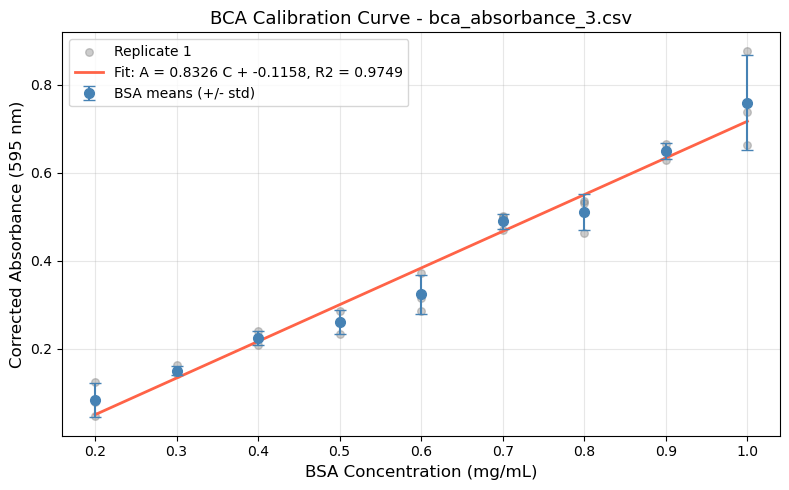

Figure saved: calibration_curve_bca3.png


In [9]:
# Plot calibration curve
fig, ax = plt.subplots(figsize=(8, 5))

# Individual points from the 3 replicates (grey, subtle)
for group in [1, 2, 3]:
    g = bsa_df[bsa_df['Group'] == group]
    ax.scatter(g['BSA_concentration_mg_mL'], g['Abs_corrected_mean'],
               alpha=0.4, s=30, color='gray', zorder=2, label=f'Replicate {group}' if group == 1 else '')

# Replicate means with error bars
ax.errorbar(
    bsa_stats['BSA_concentration_mg_mL'],
    bsa_stats['Abs_mean'],
    yerr=bsa_stats['Abs_std'],
    fmt='o', color='steelblue', markersize=7, capsize=4,
    label='BSA means (+/- std)', zorder=3
)

# Regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color='tomato', linewidth=2,
        label=f'Fit: A = {slope:.4f} C + {intercept:.4f}, R2 = {r_squared:.4f}')

ax.set_xlabel('BSA Concentration (mg/mL)', fontsize=12)
ax.set_ylabel('Corrected Absorbance (595 nm)', fontsize=12)
ax.set_title('BCA Calibration Curve - bca_absorbance_3.csv', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('calibration_curve_bca3.png', dpi=150)
plt.show()
print('Figure saved: calibration_curve_bca3.png')

## Section 10: Residual Analysis

Residuals are the differences between measured values and values predicted by the model.  
A good linear model produces random residuals, distributed symmetrically around zero.  
A systematic pattern would indicate non-linearity.

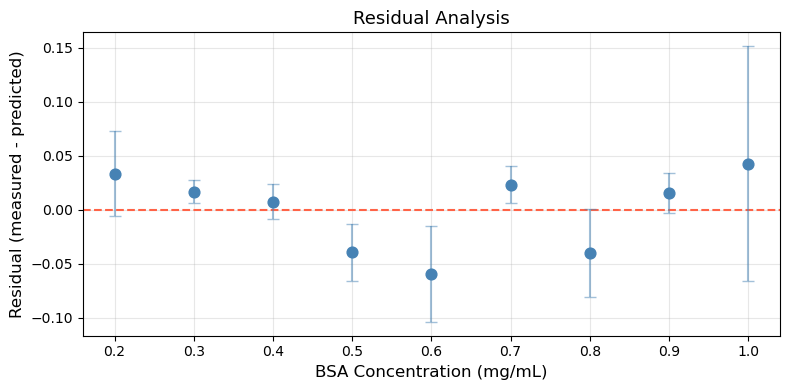

In [10]:
# Predicted values and residuals
y_pred = slope * x + intercept
residuals = y - y_pred

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(x, residuals, color='steelblue', s=60, zorder=3)
ax.axhline(0, color='tomato', linewidth=1.5, linestyle='--')

# Error bars on residuals
ax.errorbar(x, residuals,
            yerr=bsa_stats['Abs_std'].values,
            fmt='none', color='steelblue', alpha=0.5, capsize=4)

ax.set_xlabel('BSA Concentration (mg/mL)', fontsize=12)
ax.set_ylabel('Residual (measured - predicted)', fontsize=12)
ax.set_title('Residual Analysis', fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('residuals_bca3.png', dpi=150)
plt.show()

## Section 11: Prot X Concentration Calculation

We invert the calibration curve to obtain concentration:

**C = (A_corrected - b) / a**

For unknowns, the correction used the **mean blank** of all 3 groups (Blank 1, 2, 3) for each technical read.  
The **dilution factor** is applied to recover the concentration in the original sample.

In [11]:
# Extract unknowns from condition_summary
prot_x = condition_summary[condition_summary['Sample_Type'] == 'Unknown'].copy()

# Calculate concentration from corrected absorbance
prot_x['Concentration_measured_mg_mL'] = (
    (prot_x['Abs_corrected_mean'] - intercept) / slope
).round(4)

prot_x['Concentration_initial_mg_mL'] = (
    prot_x['Concentration_measured_mg_mL'] * prot_x['Dilution_factor']
).round(4)

# Results table
results_prot_x = prot_x[[
    'Experiment', 'Well_ID',
    'Abs_corrected_mean', 'Abs_corrected_std',
    'Dilution_factor',
    'Concentration_measured_mg_mL',
    'Concentration_initial_mg_mL'
]].reset_index(drop=True)

print('Prot X concentrations:')
results_prot_x

Prot X concentrations:


,Experiment,Well_ID,Abs_corrected_mean,Abs_corrected_std,Dilution_factor,Concentration_measured_mg_mL,Concentration_initial_mg_mL
0,Prot X_d10,D5,-0.003444,0.000192,10.0,0.1350,1.3500
1,Prot X_d2,B5,0.000556,0.000192,2.0,0.1398,0.2796
2,Prot X_d5,C5,-0.003444,0.000192,5.0,0.1350,0.6750
3,Prot X_stock,A5,0.083222,0.001503,1.0,0.2391,0.2391


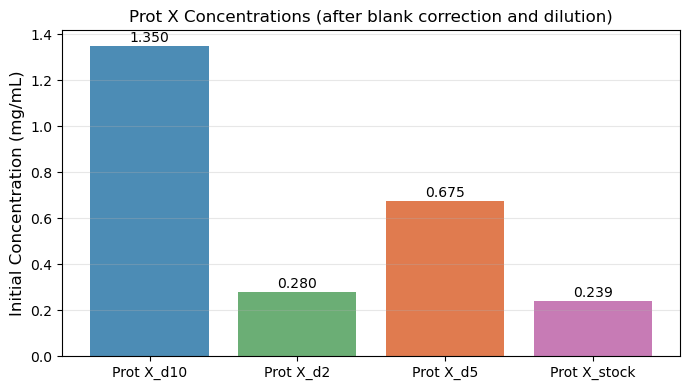

In [12]:
# Bar chart of initial concentrations
fig, ax = plt.subplots(figsize=(7, 4))

names = results_prot_x['Experiment'].tolist()
concs = results_prot_x['Concentration_initial_mg_mL'].tolist()

bars = ax.bar(names, concs, color=['#4C8CB5', '#6BAE75', '#E07B4F', '#C77BB5'])

for bar, val in zip(bars, concs):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Initial Concentration (mg/mL)', fontsize=12)
ax.set_title('Prot X Concentrations (after blank correction and dilution)', fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('concentrations_protX_bca3.png', dpi=150)
plt.show()

## Section 12: Export Results

Three CSV files are exported:
- `condition_summary_bca3.csv`: blank-corrected and averaged absorbances for all conditions
- `bsa_stats_bca3.csv`: BSA statistics by concentration (means of 3 replicates)
- `concentrations_protX_bca3.csv`: calculated concentrations for Prot X

In [13]:
condition_summary.to_csv('condition_summary_bca3.csv', index=False, sep=';')
bsa_stats.to_csv('bsa_stats_bca3.csv', index=False, sep=';')
results_prot_x.to_csv('concentrations_protX_bca3.csv', index=False, sep=';')

print('Files exported:')
print('  - condition_summary_bca3.csv')
print('  - bsa_stats_bca3.csv')
print('  - concentrations_protX_bca3.csv')
print()
print('=== Summary ===')
print(f'Calibration: A = {slope:.4f} x C + {intercept:.4f}')
print(f'R2 = {r_squared:.4f}')
print()
print('Prot X concentrations (initial stock):')
for _, row in results_prot_x.iterrows():
    print(f'  {row["Experiment"]:15s} -> {row["Concentration_initial_mg_mL"]:.4f} mg/mL')

Files exported:
  - condition_summary_bca3.csv
  - bsa_stats_bca3.csv
  - concentrations_protX_bca3.csv

=== Summary ===
Calibration: A = 0.8326 x C + -0.1158
R2 = 0.9749

Prot X concentrations (initial stock):
  Prot X_d10      -> 1.3500 mg/mL
  Prot X_d2       -> 0.2796 mg/mL
  Prot X_d5       -> 0.6750 mg/mL
  Prot X_stock    -> 0.2391 mg/mL
